# Buổi 6 (ví dụ 2) — MLP và lan truyền ngược: dự đoán giao hàng trễ

Notebook này là ví dụ thứ hai cho bài lan truyền ngược, dựa trên tài liệu
*Ví dụ MLP và lan truyền ngược — Dự đoán giao hàng trễ*. Nó đi song song với
[`06_backprop_cpu_quat.ipynb`](06_backprop_cpu_quat.ipynb) nhưng đổi bài toán:

| | Ví dụ 1 (CPU – quạt) | Ví dụ 2 (giao hàng trễ) |
|---|---|---|
| Số feature | 2 | 3 |
| Số mẫu | 4 | 8 |
| Kiến trúc tính tay | `2 → 2 → 1` | `3 → 2 → 1` |
| Kiến trúc huấn luyện | `2 → 2 → 1` | `3 → 3 → 1` |
| Quan hệ nhãn | XOR | **MAJORITY** (2 trong 3) |

**Bảng thuật ngữ Anh – Việt** đã có ở phần đầu notebook `06_backprop_cpu_quat.ipynb`;
notebook này dùng lại đúng các thuật ngữ đó (forward/lan truyền xuôi, delta/tín hiệu lỗi,
upstream × local, v.v.) nên bạn nên mở sẵn bảng đó bên cạnh.

Nội dung:

1. Bối cảnh giao hàng và bảng dữ liệu 8 tình huống.
2. **Một phát hiện quan trọng**: nhãn của bài toán này *có* tách được tuyến tính — khác
   hẳn XOR. Ta kiểm chứng bằng code và bàn xem điều đó có nghĩa gì.
3. Kiến trúc `3 → 2 → 1` dùng để tính tay.
4. Lan truyền xuôi cho một đơn hàng, đối chiếu từng số với tài liệu.
5. Lan truyền ngược tại tầng ra.
6. Lan truyền ngược tại tầng ẩn, và vì sao cột "mưa" có gradient bằng 0.
7. Cập nhật tham số, diễn giải bằng ngôn ngữ nghiệp vụ.
8. Kiểm tra gradient bằng phương pháp số.
9. Huấn luyện `3 → 3 → 1` trên cả 8 mẫu.
10. Tầng ẩn có thật sự học "xa ∧ cao điểm" như tài liệu gợi ý?
11. Khi nào **thật sự** cần tầng ẩn: biến thể "đúng hai điều kiện bất lợi".
12. Thí nghiệm learning rate và số nơ-ron ẩn.
13. Mở rộng sang dữ liệu liên tục: train/test, confusion matrix, precision/recall, chọn ngưỡng.
14. Bài tập, hoạt động nhóm, câu hỏi thảo luận, giới hạn.

## 1. Bối cảnh và dữ liệu

Một ứng dụng giao đồ ăn muốn trả lời: **đơn hàng này có khả năng bị giao trễ không?**

Phiên bản nhập môn dùng ba đầu vào nhị phân (`0` = không, `1` = có):

- $x_1$: địa chỉ giao hàng có **xa** không?
- $x_2$: có đang trong **giờ cao điểm** không?
- $x_3$: trời có **mưa** không?
- $y$: đơn hàng có bị **giao trễ** không?

> Đây là dữ liệu giả lập để tính toán trên lớp, không phải dữ liệu hay ngưỡng vận hành thực tế.

Ý tưởng nghiệp vụ: **một yếu tố đơn lẻ thường chưa đủ gây trễ, nhưng hai yếu tố cùng lúc
thì có.** Đơn xa mà đường thoáng, trời tốt vẫn kịp; đơn gần mà vừa mưa vừa tắc thì trễ.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# X = [xa, giờ cao điểm, mưa]
X = np.array([
    [0., 0., 0.],   # gần, thoáng, trời tốt
    [0., 1., 0.],   # gần nhưng cao điểm
    [1., 0., 0.],   # xa nhưng đường thoáng
    [1., 1., 0.],   # xa + cao điểm
    [0., 0., 1.],   # gần, có mưa
    [0., 1., 1.],   # cao điểm + mưa
    [1., 0., 1.],   # xa + mưa
    [1., 1., 1.],   # cả ba bất lợi
])

y = np.array([[0.], [0.], [0.], [1.], [0.], [1.], [1.], [1.]])

bang = pd.DataFrame({
    "x1_xa": X[:, 0].astype(int),
    "x2_cao_diem": X[:, 1].astype(int),
    "x3_mua": X[:, 2].astype(int),
    "so_yeu_to_bat_loi": X.sum(axis=1).astype(int),
    "y_giao_tre": y[:, 0].astype(int),
    "giai_thich": [
        "Gần, đường thoáng, thời tiết tốt",
        "Gần nên vẫn kịp dù cao điểm",
        "Xa nhưng đường thoáng",
        "Xa VÀ đang giờ cao điểm",
        "Gần, mưa ảnh hưởng chưa lớn",
        "Cao điểm VÀ mưa",
        "Xa VÀ mưa",
        "Cả ba điều kiện đều bất lợi",
    ],
})
display(bang)

print("X.shape =", X.shape, "| y.shape =", y.shape)

,x1_xa,x2_cao_diem,x3_mua,so_yeu_to_bat_loi,y_giao_tre,giai_thich
0,0,0,0,0,0,"Gần, đường thoáng, thời tiết tốt"
1,0,1,0,1,0,Gần nên vẫn kịp dù cao điểm
2,1,0,0,1,0,Xa nhưng đường thoáng
3,1,1,0,2,1,Xa VÀ đang giờ cao điểm
4,0,0,1,1,0,"Gần, mưa ảnh hưởng chưa lớn"
5,0,1,1,2,1,Cao điểm VÀ mưa
6,1,0,1,2,1,Xa VÀ mưa
7,1,1,1,3,1,Cả ba điều kiện đều bất lợi


X.shape = (8, 3) | y.shape = (8, 1)


Nhìn cột `so_yeu_to_bat_loi` cạnh cột `y_giao_tre`, một quy luật lộ ra rất rõ.

In [2]:
so_bat_loi = X.sum(axis=1)

print("Số yếu tố bất lợi :", so_bat_loi.astype(int))
print("Nhãn giao trễ     :", y[:, 0].astype(int))
print()
print("Nhãn có đúng bằng '(số yếu tố bất lợi) >= 2' không?",
      np.array_equal(y[:, 0], (so_bat_loi >= 2).astype(float)))

Số yếu tố bất lợi : [0 1 1 2 1 2 2 3]
Nhãn giao trễ     : [0 0 0 1 0 1 1 1]

Nhãn có đúng bằng '(số yếu tố bất lợi) >= 2' không? True


Nhãn đúng bằng quy tắc **"từ 2 trong 3 yếu tố bất lợi trở lên thì trễ"**. Trong logic, hàm
này tên là **MAJORITY** (*hàm đa số*): kết quả chỉ phụ thuộc vào việc *có bao nhiêu* yếu tố
bất lợi, **không** phụ thuộc vào việc đó là những yếu tố nào.

Ba tổ hợp mà tài liệu nhắc tới — xa∧cao điểm, xa∧mưa, cao điểm∧mưa — thực chất là ba cách
để "đếm được 2". Ghi nhận này sẽ rất quan trọng ở phần 2 và phần 10.

## 2. Một phát hiện quan trọng: bài toán này **tách được tuyến tính**

Ở ví dụ CPU – quạt, nhãn là XOR và ta đã chứng minh một Perceptron *không thể* giải được.
Rất dễ mang theo kết luận đó sang đây và nghĩ rằng "cần tầng ẩn vì phải học tổ hợp hai yếu
tố". Nhưng hàm MAJORITY thì khác XOR: nó **tách được tuyến tính** (*linearly separable*).

Lý do đơn giản đến mức có thể viết ra nghiệm bằng tay. Đặt trọng số bằng nhau và ngưỡng
giữa 1 và 2:

$$
\text{net} = x_1 + x_2 + x_3 - 1.5
$$

Khi có 0 hoặc 1 yếu tố bất lợi thì $\text{net} < 0$; khi có 2 hoặc 3 thì $\text{net} > 0$.
Đúng bằng nhãn. Ta kiểm chứng ngay.

In [3]:
# Nghiệm đặt tay: đếm số yếu tố bất lợi, ngưỡng ở 1.5
w_tay = np.array([1.0, 1.0, 1.0])
b_tay = -1.5

net_tay = X @ w_tay + b_tay
du_doan_tay = (net_tay >= 0).astype(float)

bang_tay = pd.DataFrame({
    "x1_xa": X[:, 0].astype(int),
    "x2_cao_diem": X[:, 1].astype(int),
    "x3_mua": X[:, 2].astype(int),
    "net = x1+x2+x3-1.5": net_tay,
    "dự đoán": du_doan_tay.astype(int),
    "y_nhãn": y[:, 0].astype(int),
})
display(bang_tay)

print("Accuracy của MỘT Perceptron đặt tay =", (du_doan_tay == y[:, 0]).mean())
assert (du_doan_tay == y[:, 0]).mean() == 1.0

,x1_xa,x2_cao_diem,x3_mua,net = x1+x2+x3-1.5,dự đoán,y_nhãn
0,0,0,0,-1.5,0,0
1,0,1,0,-0.5,0,0
2,1,0,0,-0.5,0,0
3,1,1,0,0.5,1,1
4,0,0,1,-0.5,0,0
5,0,1,1,0.5,1,1
6,1,0,1,0.5,1,1
7,1,1,1,1.5,1,1


Accuracy của MỘT Perceptron đặt tay = 1.0


In [4]:
def perceptron_hoc(X, y, so_epoch=300, eta=0.1, seed=0):
    # Quy tắc học Perceptron của buổi 4, hàm bước 0/1
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, size=X.shape[1])
    b = 0.0
    t = y[:, 0]
    for _ in range(so_epoch):
        for xi, ti in zip(X, t):
            y_hat = 1.0 if w @ xi + b >= 0 else 0.0
            e = ti - y_hat
            w += eta * e * xi
            b += eta * e
    du_doan = (X @ w + b >= 0).astype(float)
    return w, b, du_doan, (du_doan == t).mean()


print("Để Perceptron TỰ HỌC thay vì đặt tay:")
for seed in range(5):
    w_p, b_p, dd, acc = perceptron_hoc(X, y, seed=seed)
    print(f"  seed={seed} | accuracy = {acc:.2f} | w = {np.round(w_p, 2)} | b = {b_p:.2f}")

Để Perceptron TỰ HỌC thay vì đặt tay:
  seed=0 | accuracy = 1.00 | w = [0.16 0.13 0.12] | b = -0.20
  seed=1 | accuracy = 1.00 | w = [0.17 0.21 0.17] | b = -0.30
  seed=2 | accuracy = 1.00 | w = [0.19 0.04 0.19] | b = -0.20
  seed=3 | accuracy = 1.00 | w = [0.42 0.22 0.41] | b = -0.50
  seed=4 | accuracy = 1.00 | w = [0.27 0.21 0.23] | b = -0.40


Perceptron một tầng đạt accuracy **1.00** với mọi khởi tạo, và các trọng số nó học được
đều xấp xỉ bằng nhau — tức nó cũng tự phát hiện ra "chỉ cần đếm số yếu tố bất lợi".

Vậy rút ra điều gì?

- Bài toán 8 tình huống này **không đòi hỏi** tầng ẩn. Ta vẫn dùng MLP để **học cách tính
  forward/backward**, nhưng phải trung thực rằng đây là chọn mô hình *mạnh hơn mức cần thiết*.
- "Kết quả phụ thuộc tổ hợp nhiều yếu tố" **không đồng nghĩa** với "phi tuyến". Ở đây các
  yếu tố chỉ cần **cộng dồn** lại rồi so với một ngưỡng — đó vẫn là tuyến tính.
- Phi tuyến thật sự xuất hiện khi quan hệ **không đơn điệu**: thêm một yếu tố bất lợi lại
  làm nhãn *đổi chiều*. XOR là vậy, và phần 11 sẽ dựng một biến thể giao hàng đúng kiểu đó.

> Đây là kỹ năng nghề quan trọng: trước khi chọn mạng nơ-ron, hãy thử một mô hình tuyến
> tính. Nếu nó đã đủ tốt, mô hình phức tạp chỉ thêm rủi ro và khó giải thích.

Phần còn lại của notebook vẫn dùng MLP, vì mục tiêu buổi học là hiểu **thuật toán lan
truyền ngược** — và một bài toán nhỏ, kiểm tra được từng con số là môi trường tốt nhất để
học thuật toán đó.

## 3. Kiến trúc dùng để tính tay: `3 → 2 → 1`

Tài liệu đề xuất `3 → 3 → 1` khi chạy code, nhưng để tính tay gọn hơn thì dùng `3 → 2 → 1`.

```text
   x1 (xa) ──┐
             ├──▶ h1 ──┐
   x2 (cao ──┤         ├──▶ ŷ (xác suất trễ) ──▶ L
      điểm)  ├──▶ h2 ──┘
   x3 (mưa) ─┘
```

Tham số và kích thước:

$$
\mathbf{x}\in\mathbb{R}^{3\times1},\quad
\mathbf{W}^{(1)}\in\mathbb{R}^{2\times3},\quad
\mathbf{b}^{(1)}\in\mathbb{R}^{2\times1},\quad
\mathbf{W}^{(2)}\in\mathbb{R}^{1\times2},\quad
b^{(2)}\in\mathbb{R}
$$

Công thức lượt xuôi và hàm loss giống hệt ví dụ CPU – quạt:

$$
\mathbf{z}^{(1)} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)},\quad
\mathbf{a}^{(1)} = \sigma(\mathbf{z}^{(1)}),\quad
z^{(2)} = \mathbf{W}^{(2)}\mathbf{a}^{(1)} + b^{(2)},\quad
\hat y = \sigma(z^{(2)})
$$

$$
\sigma(z)=\frac{1}{1+e^{-z}},\qquad
\sigma'(z)=\sigma(z)\bigl(1-\sigma(z)\bigr)=a(1-a),\qquad
L=\tfrac12(\hat y-y)^2
$$

Điều **duy nhất** thay đổi so với ví dụ trước là $\mathbf{W}^{(1)}$ có 3 cột thay vì 2.
Toàn bộ công thức backward giữ nguyên — đó chính là điểm mạnh của cách viết dạng ma trận.

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_grad_tu_activation(a):
    # Đạo hàm sigmoid khi đã biết activation a = sigmoid(z)
    return a * (1.0 - a)


print("sigmoid(0.7)    =", round(float(sigmoid(0.7)), 4))
print("sigmoid(0.4)    =", round(float(sigmoid(0.4)), 4))
print("sigmoid(0.2684) =", round(float(sigmoid(0.2684)), 4))

sigmoid(0.7)    = 0.6682
sigmoid(0.4)    = 0.5987
sigmoid(0.2684) = 0.5667


## 4. Lan truyền xuôi cho một đơn hàng

Xét đơn hàng trong tài liệu: **xa, đang giờ cao điểm, không mưa** — và thực tế đã **bị trễ**.

$$
\mathbf{x}=\begin{bmatrix}1\\1\\0\end{bmatrix},\qquad y=1
$$

Trọng số khởi tạo:

$$
\mathbf{W}^{(1)}=\begin{bmatrix}0.4&0.5&-0.2\\-0.3&0.6&0.4\end{bmatrix},\quad
\mathbf{b}^{(1)}=\begin{bmatrix}-0.2\\0.1\end{bmatrix},\quad
\mathbf{W}^{(2)}=\begin{bmatrix}0.7&-0.5\end{bmatrix},\quad
b^{(2)}=0.1,\quad \eta=0.5
$$

Đọc $\mathbf{W}^{(1)}$ theo nghĩa nghiệp vụ: dòng 1 là nơ-ron ẩn $h_1$, nó đang coi "xa"
(+0.4) và "cao điểm" (+0.5) là dấu hiệu xấu, còn "mưa" (−0.2) là dấu hiệu tốt — vô lý,
nhưng đó chỉ là khởi tạo ngẫu nhiên. Huấn luyện là quá trình sửa những con số vô lý này.

In [6]:
# Tham số khởi tạo đúng như tài liệu (dạng cột, khớp công thức toán)
W1 = np.array([[0.4, 0.5, -0.2],
               [-0.3, 0.6, 0.4]])
b1 = np.array([[-0.2],
               [0.1]])
W2 = np.array([[0.7, -0.5]])
b2 = np.array([[0.1]])
eta = 0.5

# Đơn hàng: xa, cao điểm, không mưa -> thực tế bị trễ
x = np.array([[1.0],
              [1.0],
              [0.0]])
t = 1.0

# --- LAN TRUYỀN XUÔI ---
z1 = W1 @ x + b1          # (2,1)
a1 = sigmoid(z1)          # (2,1)
z2 = W2 @ a1 + b2         # (1,1)
y_hat = sigmoid(z2)       # (1,1)
L = 0.5 * (y_hat - t).item() ** 2

print("z1 =", np.round(z1.ravel(), 5))
print("a1 =", np.round(a1.ravel(), 5))
print("z2 =", round(z2.item(), 5))
print("y_hat =", round(y_hat.item(), 5), f"-> xác suất trễ ~ {y_hat.item()*100:.2f}%")
print("L =", round(L, 5))

z1 = [0.7 0.4]
a1 = [0.66819 0.59869]
z2 = 0.26839
y_hat = 0.5667 -> xác suất trễ ~ 56.67%
L = 0.09388


In [7]:
# Truy vết lượt xuôi: mỗi dòng là một mắt xích của đồ thị tính toán
truy_vet = [
    ("x",     "input",                         "dữ liệu đơn hàng",          x),
    ("z^(1)", "net input (hidden)",            "tổng có trọng số, tầng ẩn", z1),
    ("a^(1)", "activation (hidden)",           "kích hoạt, tầng ẩn",        a1),
    ("z^(2)", "net input (output)",            "tổng có trọng số, tầng ra", z2),
    ("y_hat", "prediction / activation (out)", "xác suất giao trễ",         y_hat),
]
display(pd.DataFrame([{
    "đại lượng": ten, "English": en, "Tiếng Việt": vi,
    "shape": str(v.shape), "giá trị": np.round(v.ravel(), 5),
} for ten, en, vi, v in truy_vet]))

print("Chuỗi shape:", f"W1 {W1.shape} @ x {x.shape} -> z1 {z1.shape};",
      f"W2 {W2.shape} @ a1 {a1.shape} -> z2 {z2.shape}")

# Đối chiếu với bảng forward trong tài liệu
bang_fw = pd.DataFrame({
    "đại lượng": ["z1^(1)", "a1^(1)", "z2^(1)", "a2^(1)", "z^(2)", "y_hat", "L"],
    "code tính được": [z1[0, 0].item(), a1[0, 0].item(), z1[1, 0].item(),
                       a1[1, 0].item(), z2.item(), y_hat.item(), L],
    "tài liệu": [0.7, 0.6682, 0.4, 0.5987, 0.2684, 0.5667, 0.0939],
})
bang_fw["chênh lệch"] = (bang_fw["code tính được"] - bang_fw["tài liệu"]).abs()
display(bang_fw.round(6))
assert bang_fw["chênh lệch"].max() < 1e-4, "Số liệu forward lệch so với tài liệu!"
print("Khớp với bảng tính tay trong tài liệu.")

,đại lượng,English,Tiếng Việt,shape,giá trị
0,x,input,dữ liệu đơn hàng,"(3, 1)","[1.0, 1.0, 0.0]"
1,z^(1),net input (hidden),"tổng có trọng số, tầng ẩn","(2, 1)","[0.7, 0.4]"
2,a^(1),activation (hidden),"kích hoạt, tầng ẩn","(2, 1)","[0.66819, 0.59869]"
3,z^(2),net input (output),"tổng có trọng số, tầng ra","(1, 1)",[0.26839]
4,y_hat,prediction / activation (out),xác suất giao trễ,"(1, 1)",[0.5667]


Chuỗi shape: W1 (2, 3) @ x (3, 1) -> z1 (2, 1); W2 (1, 2) @ a1 (2, 1) -> z2 (1, 1)


,đại lượng,code tính được,tài liệu,chênh lệch
0,z1^(1),0.700000,0.7000,0.000000
1,a1^(1),0.668188,0.6682,0.000012
2,z2^(1),0.400000,0.4000,0.000000
3,a2^(1),0.598688,0.5987,0.000012
4,z^(2),0.268388,0.2684,0.000012
5,y_hat,0.566697,0.5667,0.000003
6,L,0.093876,0.0939,0.000024


Khớp với bảng tính tay trong tài liệu.


Diễn giải: mạng cho xác suất trễ khoảng **56.67%**, trong khi đơn hàng này *thực tế đã
trễ* (nhãn 1). Mức cảnh báo như vậy là **quá thấp** — nếu ngưỡng cảnh báo của hệ thống là
0.5 thì may mắn vẫn báo đúng, nhưng biên an toàn gần như bằng không. Loss $\approx 0.094$
định lượng chính sự "chưa đủ dứt khoát" đó.

## 5. Lan truyền ngược tại tầng ra

Mạng đang sai. Câu hỏi của backpropagation: **mỗi tham số chịu trách nhiệm bao nhiêu?**

Bắt đầu từ đầu ra, ghép hai mắt xích thành delta tầng ra:

$$
\delta^{(2)} = \frac{\partial L}{\partial z^{(2)}}
= \underbrace{(\hat y - y)}_{\partial L/\partial\hat y}
\cdot \underbrace{\hat y(1-\hat y)}_{\partial\hat y/\partial z^{(2)}}
$$

$$
\frac{\partial L}{\partial \mathbf{W}^{(2)}} = \delta^{(2)}\bigl(\mathbf{a}^{(1)}\bigr)^{\top},
\qquad
\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)}
$$

In [8]:
# --- BACKWARD TẦNG RA ---
dL_dyhat = y_hat - t                       # (1,1)
dyhat_dz2 = y_hat * (1 - y_hat)            # (1,1)
delta2 = dL_dyhat * dyhat_dz2              # (1,1)

dW2 = delta2 @ a1.T                        # (1,1)@(1,2) -> (1,2)
db2 = delta2

print("dL/dy_hat  =", round(dL_dyhat.item(), 5))
print("dy_hat/dz2 =", round(dyhat_dz2.item(), 5))
print("delta2     =", round(delta2.item(), 5))
print("dW2        =", np.round(dW2.ravel(), 5))
print("db2        =", round(db2.item(), 5))

bang_ra = pd.DataFrame({
    "đại lượng": ["delta2", "dW2[0] (h1->ra)", "dW2[1] (h2->ra)", "db2"],
    "code tính được": [delta2.item(), dW2[0, 0].item(), dW2[0, 1].item(), db2.item()],
    "tài liệu": [-0.1064, -0.0711, -0.0637, -0.1064],
})
bang_ra["chênh lệch"] = (bang_ra["code tính được"] - bang_ra["tài liệu"]).abs()
display(bang_ra.round(6))
assert bang_ra["chênh lệch"].max() < 1e-4

dL/dy_hat  = -0.4333
dy_hat/dz2 = 0.24555
delta2     = -0.1064
dW2        = [-0.07109 -0.0637 ]
db2        = -0.1064


,đại lượng,code tính được,tài liệu,chênh lệch
0,delta2,-0.106398,-0.1064,0.000002
1,dW2[0] (h1->ra),-0.071094,-0.0711,0.000006
2,dW2[1] (h2->ra),-0.063699,-0.0637,0.000001
3,db2,-0.106398,-0.1064,0.000002


$\delta^{(2)} \approx -0.106$ **âm**, nghĩa là loss sẽ giảm nếu ta làm $z^{(2)}$ **tăng** —
đúng như kỳ vọng, vì mạng đang cảnh báo quá nhẹ so với nhãn.

Hai gradient của $\mathbf{W}^{(2)}$ tỉ lệ với activation tương ứng: $h_1$ kích hoạt mạnh
hơn (0.668 so với 0.599) nên trọng số nối từ $h_1$ bị sửa nhiều hơn (−0.0711 so với
−0.0637). Nguyên tắc chung: **nơ-ron nào "nói to" hơn thì phải chịu trách nhiệm nhiều hơn.**

## 6. Lan truyền ngược tại tầng ẩn

Không ai nói cho $h_1$, $h_2$ biết giá trị đúng của chúng phải là bao nhiêu. Tín hiệu lỗi
phải được tầng ra truyền về, có trọng số theo mức độ ảnh hưởng:

$$
\boldsymbol{\delta}^{(1)} =
\bigl(\mathbf{W}^{(2)}\bigr)^{\top}\delta^{(2)}
\;\odot\;
\mathbf{a}^{(1)}\odot\bigl(1-\mathbf{a}^{(1)}\bigr)
\qquad\Longrightarrow\qquad
\frac{\partial L}{\partial\mathbf{W}^{(1)}} = \boldsymbol{\delta}^{(1)}\mathbf{x}^{\top},
\quad
\frac{\partial L}{\partial\mathbf{b}^{(1)}} = \boldsymbol{\delta}^{(1)}
$$

> Phải dùng $\mathbf{W}^{(2)}$ **trước khi cập nhật**. Nếu sửa tầng ra trước rồi mới lan
> truyền về tầng ẩn, ta đang dùng sai đạo hàm.

In [9]:
# --- BACKWARD TẦNG ẨN ---
sigma_grad_z1 = sigmoid_grad_tu_activation(a1)   # (2,1)
loi_truyen_ve = W2.T @ delta2                    # (2,1)@(1,1) -> (2,1)
delta1 = loi_truyen_ve * sigma_grad_z1           # (2,1)

dW1 = delta1 @ x.T                               # (2,1)@(1,3) -> (2,3)
db1 = delta1

print("sigma'(z1)                   =", np.round(sigma_grad_z1.ravel(), 5))
print("lỗi truyền về (W2^T · delta2) =", np.round(loi_truyen_ve.ravel(), 5))
print("delta1                       =", np.round(delta1.ravel(), 5))
print("\ndW1 (dòng = nơ-ron ẩn, cột = xa / cao điểm / mưa):")
display(pd.DataFrame(np.round(dW1, 5), index=["h1", "h2"],
                     columns=["x1_xa", "x2_cao_diem", "x3_mua"]))
print("db1 =", np.round(db1.ravel(), 5))

bang_an = pd.DataFrame({
    "đại lượng": ["delta1_1", "delta1_2", "dW1[h1,xa]", "dW1[h1,cao_diem]",
                  "dW1[h1,mua]", "dW1[h2,xa]", "dW1[h2,mua]"],
    "code tính được": [delta1[0, 0].item(), delta1[1, 0].item(),
                       dW1[0, 0].item(), dW1[0, 1].item(), dW1[0, 2].item(),
                       dW1[1, 0].item(), dW1[1, 2].item()],
    "tài liệu": [-0.0165, 0.0128, -0.0165, -0.0165, 0.0, 0.0128, 0.0],
})
bang_an["chênh lệch"] = (bang_an["code tính được"] - bang_an["tài liệu"]).abs()
display(bang_an.round(6))
assert bang_an["chênh lệch"].max() < 1e-4
print("Khớp với phần tính tay của tài liệu.")

sigma'(z1)                   = [0.22171 0.24026]
lỗi truyền về (W2^T · delta2) = [-0.07448  0.0532 ]
delta1                       = [-0.01651  0.01278]

dW1 (dòng = nơ-ron ẩn, cột = xa / cao điểm / mưa):


,x1_xa,x2_cao_diem,x3_mua
h1,-0.01651,-0.01651,0.0
h2,0.01278,0.01278,0.0


db1 = [-0.01651  0.01278]


,đại lượng,code tính được,tài liệu,chênh lệch
0,delta1_1,-0.016513,-0.0165,0.000013
1,delta1_2,0.012782,0.0128,0.000018
2,"dW1[h1,xa]",-0.016513,-0.0165,0.000013
3,"dW1[h1,cao_diem]",-0.016513,-0.0165,0.000013
4,"dW1[h1,mua]",0.000000,0.0000,0.000000
5,"dW1[h2,xa]",0.012782,0.0128,0.000018
6,"dW1[h2,mua]",0.000000,0.0000,0.000000


Khớp với phần tính tay của tài liệu.


Ba điểm cần giải thích:

**Vì sao hai delta trái dấu?** $\mathbf{W}^{(2)} = [0.7, -0.5]$: $h_1$ đẩy xác suất trễ
lên, $h_2$ kéo xuống. Muốn tăng cảnh báo, mạng phải tăng $h_1$ và giảm $h_2$.

**Vì sao cột "mưa" có gradient bằng 0?** Vì
$\partial L/\partial W^{(1)}_{ij} = \delta^{(1)}_i x_j$ và đơn hàng này có $x_3 = 0$ (không
mưa). Tín hiệu "mưa" không tham gia vào tổng có trọng số, nên **không có căn cứ nào** để
sửa các kết nối đi ra từ nó. Nói theo nghiệp vụ: *không thể học gì về ảnh hưởng của mưa từ
một đơn hàng không mưa.* Muốn học điều đó, phải có mẫu với $x_3 = 1$.

**Bias thì sao?** $\partial L/\partial b^{(1)} = \boldsymbol{\delta}^{(1)} \ne 0$. Bias
luôn được cập nhật vì input của nó luôn bằng 1.

## 7. Cập nhật tham số và diễn giải nghiệp vụ

$$
\theta_{\text{mới}} = \theta_{\text{cũ}} - \eta\,\frac{\partial L}{\partial\theta},
\qquad \eta = 0.5
$$

In [10]:
W1_cu, b1_cu, W2_cu, b2_cu = W1.copy(), b1.copy(), W2.copy(), b2.copy()

# Tính xong TOÀN BỘ gradient ở trên rồi mới cập nhật
W2_moi = W2 - eta * dW2
b2_moi = b2 - eta * db2
W1_moi = W1 - eta * dW1
b1_moi = b1 - eta * db1

print("W2:", np.round(W2_cu.ravel(), 5), "->", np.round(W2_moi.ravel(), 5))
print("b2:", round(b2_cu.item(), 5), "->", round(b2_moi.item(), 5))
print("b1:", np.round(b1_cu.ravel(), 5), "->", np.round(b1_moi.ravel(), 5))
print("\nW1 sau cập nhật:")
display(pd.DataFrame(np.round(W1_moi, 5), index=["h1", "h2"],
                     columns=["x1_xa", "x2_cao_diem", "x3_mua"]))

bang_cn = pd.DataFrame({
    "tham số": ["W2[0]", "W2[1]", "b2", "W1[h1,xa]", "W1[h1,cao_diem]",
                "W1[h2,xa]", "W1[h2,cao_diem]", "b1_1", "b1_2"],
    "code tính được": [W2_moi[0, 0].item(), W2_moi[0, 1].item(), b2_moi.item(),
                       W1_moi[0, 0].item(), W1_moi[0, 1].item(),
                       W1_moi[1, 0].item(), W1_moi[1, 1].item(),
                       b1_moi[0, 0].item(), b1_moi[1, 0].item()],
    "tài liệu": [0.7356, -0.4682, 0.1532, 0.4083, 0.5083,
                 -0.3064, 0.5936, -0.1918, 0.0936],
})
bang_cn["chênh lệch"] = (bang_cn["code tính được"] - bang_cn["tài liệu"]).abs()
display(bang_cn.round(6))
assert bang_cn["chênh lệch"].max() < 1e-4

W2: [ 0.7 -0.5] -> [ 0.73555 -0.46815]
b2: 0.1 -> 0.1532
b1: [-0.2  0.1] -> [-0.19174  0.09361]

W1 sau cập nhật:


,x1_xa,x2_cao_diem,x3_mua
h1,0.40826,0.50826,-0.2
h2,-0.30639,0.59361,0.4


,tham số,code tính được,tài liệu,chênh lệch
0,W2[0],0.735547,0.7356,0.000053
1,W2[1],-0.468150,-0.4682,0.000050
2,b2,0.153199,0.1532,0.000001
3,"W1[h1,xa]",0.408256,0.4083,0.000044
4,"W1[h1,cao_diem]",0.508256,0.5083,0.000044
5,"W1[h2,xa]",-0.306391,-0.3064,0.000009
6,"W1[h2,cao_diem]",0.593609,0.5936,0.000009
7,b1_1,-0.191744,-0.1918,0.000056
8,b1_2,0.093609,0.0936,0.000009


In [11]:
def forward_mot_mau(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = sigmoid(z1)
    z2 = W2 @ a1 + b2
    return z1, a1, z2, sigmoid(z2)


_, _, _, y_hat_moi = forward_mot_mau(x, W1_moi, b1_moi, W2_moi, b2_moi)
L_moi = 0.5 * (y_hat_moi - t).item() ** 2

print(f"Trước cập nhật: xác suất trễ = {y_hat.item()*100:.2f}% | L = {L:.5f}")
print(f"Sau  cập nhật: xác suất trễ = {y_hat_moi.item()*100:.2f}% | L = {L_moi:.5f}")
print(f"Loss giảm {L - L_moi:.5f} ({(L - L_moi)/L*100:.2f}%)")
assert L_moi < L

Trước cập nhật: xác suất trễ = 56.67% | L = 0.09388
Sau  cập nhật: xác suất trễ = 59.16% | L = 0.08339
Loss giảm 0.01048 (11.16%)


Kể lại một bước học bằng ngôn ngữ nghiệp vụ:

1. Hệ thống nhận một đơn **xa, giờ cao điểm, không mưa**.
2. Mô hình dự đoán xác suất trễ **56.67%** — cảnh báo khá yếu.
3. Thực tế: đơn hàng **đã bị trễ**.
4. Backpropagation truy ngược: lỗi ở đầu ra → trách nhiệm của hai nơ-ron ẩn → trách nhiệm
   của các kết nối đi ra từ "xa" và "cao điểm". Kết nối từ "mưa" **không bị đụng đến** vì
   đơn này không mưa.
5. Các tham số được sửa, xác suất trễ cho đúng đơn này tăng lên ~57.9%.
6. Gặp đơn tương tự lần sau, mô hình sẽ cảnh báo mạnh hơn một chút.

Mức tăng chỉ ~1.2 điểm phần trăm sau **một** bước. Học là quá trình lặp lại hàng nghìn lần
như vậy trên toàn bộ dữ liệu.

> Dự đoán đi xuôi từ điều kiện giao hàng đến kết quả; trách nhiệm đối với dự đoán sai đi
> ngược từ kết quả về từng trọng số.

## 8. Kiểm tra gradient bằng phương pháp số

Làm sao chắc chắn công thức backward viết đúng? So sánh với **sai phân trung tâm**:

$$
\frac{\partial L}{\partial\theta}\approx
\frac{L(\theta+\varepsilon)-L(\theta-\varepsilon)}{2\varepsilon},\qquad \varepsilon=10^{-6}
$$

Ở mạng `3 → 2 → 1` có 11 tham số, nên kiểm tra được toàn bộ.

In [12]:
def loss_theo_tham_so(W1, b1, W2, b2, x, t):
    return 0.5 * (forward_mot_mau(x, W1, b1, W2, b2)[3] - t).item() ** 2


def gradient_so(ten, chi_so, x, t, eps=1e-6):
    # Xấp xỉ đạo hàm riêng theo một phần tử tham số, luôn làm trên bản sao
    ts = {"W1": W1_cu.copy(), "b1": b1_cu.copy(),
          "W2": W2_cu.copy(), "b2": b2_cu.copy()}
    goc = ts[ten][chi_so]

    ts[ten][chi_so] = goc + eps
    L_cong = loss_theo_tham_so(ts["W1"], ts["b1"], ts["W2"], ts["b2"], x, t)
    ts[ten][chi_so] = goc - eps
    L_tru = loss_theo_tham_so(ts["W1"], ts["b1"], ts["W2"], ts["b2"], x, t)
    return (L_cong - L_tru) / (2 * eps)


dong = []
for ten, grad in [("W1", dW1), ("b1", db1), ("W2", dW2), ("b2", db2)]:
    for idx in np.ndindex(grad.shape):
        gs = gradient_so(ten, idx, x, t)
        dong.append({"tham số": f"{ten}{idx}", "backprop": grad[idx].item(),
                     "sai phân số": gs, "sai lệch": abs(grad[idx].item() - gs)})

bang_kt = pd.DataFrame(dong)
display(bang_kt.round(9))
print("Số tham số đã kiểm tra =", len(bang_kt))
print("Sai lệch lớn nhất =", f"{bang_kt['sai lệch'].max():.2e}")
assert bang_kt["sai lệch"].max() < 1e-6, "Công thức backward có lỗi!"
print("Backpropagation khớp gradient số -> công thức đúng.")

,tham số,backprop,sai phân số,sai lệch
0,"W1(0, 0)",-0.016513,-0.016513,0.0
1,"W1(0, 1)",-0.016513,-0.016513,0.0
2,"W1(0, 2)",0.000000,0.000000,0.0
3,"W1(1, 0)",0.012782,0.012782,0.0
4,"W1(1, 1)",0.012782,0.012782,0.0
5,"W1(1, 2)",0.000000,0.000000,0.0
6,"b1(0, 0)",-0.016513,-0.016513,0.0
7,"b1(1, 0)",0.012782,0.012782,0.0
8,"W2(0, 0)",-0.071094,-0.071094,0.0
9,"W2(0, 1)",-0.063699,-0.063699,0.0


Số tham số đã kiểm tra = 11
Sai lệch lớn nhất = 1.62e-11
Backpropagation khớp gradient số -> công thức đúng.


Sai lệch ở mức $10^{-11}$, chỉ là sai số làm tròn số thực. Đáng chú ý: các tham số ứng với
input "mưa" có **cả hai** cách tính đều cho 0 — không phải công thức bị lỗi mà đúng là
gradient bằng 0 ở mẫu này.

Gradient checking rất chậm (2 lượt forward cho mỗi tham số) nên chỉ dùng để **gỡ lỗi** trên
mạng nhỏ.

## 9. Huấn luyện `3 → 3 → 1` trên cả 8 tình huống

Bây giờ dùng kiến trúc mà tài liệu đề xuất cho phần code: 3 nơ-ron ẩn, **full-batch**
(tính gradient trung bình trên cả 8 mẫu rồi cập nhật một lần mỗi epoch).

Ở dạng batch, dữ liệu xếp theo **dòng** nên các phép chuyển vị đổi vị trí:

| Toán học (một mẫu, dạng cột) | NumPy (batch, dạng dòng) |
|---|---|
| $\mathbf{z}^{(1)}=\mathbf{W}^{(1)}\mathbf{x}+\mathbf{b}^{(1)}$ | `z1 = X @ W1 + b1` |
| $\mathbf{a}^{(1)}=\sigma(\mathbf{z}^{(1)})$ | `a1 = sigmoid(z1)` |
| $z^{(2)}=\mathbf{W}^{(2)}\mathbf{a}^{(1)}+b^{(2)}$ | `z2 = a1 @ W2 + b2` |
| $\delta^{(2)}=(\hat y-y)\hat y(1-\hat y)$ | `delta2 = (y_hat-y)*y_hat*(1-y_hat)` |
| $\partial L/\partial\mathbf{W}^{(2)}=\delta^{(2)}(\mathbf{a}^{(1)})^{\top}$ | `dW2 = a1.T @ delta2 / m` |
| $\boldsymbol\delta^{(1)}=(\mathbf{W}^{(2)})^{\top}\delta^{(2)}\odot a^{(1)}(1-a^{(1)})$ | `delta1 = (delta2 @ W2.T)*a1*(1-a1)` |
| $\partial L/\partial\mathbf{W}^{(1)}=\boldsymbol\delta^{(1)}\mathbf{x}^{\top}$ | `dW1 = X.T @ delta1 / m` |

Lưu ý `W1` trong code có shape `(3, 3)` = `(số input, số nơ-ron ẩn)`, tức **chuyển vị** của
$\mathbf{W}^{(1)}$ ở phần tính tay. Đây là nguồn nhầm lẫn phổ biến nhất khi chuyển công
thức sang code.

In [13]:
def huan_luyen_mlp(X, y, so_an=3, eta=1.0, so_epoch=20000, seed=42, ghi_log_moi=2000):
    # Huấn luyện MLP (n_input -> so_an -> 1) bằng backpropagation full-batch
    rng = np.random.default_rng(seed)
    m, n_input = X.shape

    W1 = rng.normal(0, 0.5, size=(n_input, so_an))
    b1 = np.zeros((1, so_an))
    W2 = rng.normal(0, 0.5, size=(so_an, 1))
    b2 = np.zeros((1, 1))
    lich_su = []

    for epoch in range(so_epoch):
        # 1. FORWARD
        z1 = X @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        y_hat = sigmoid(z2)
        loss = 0.5 * np.mean((y_hat - y) ** 2)
        lich_su.append(loss)

        # 2. BACKWARD
        delta2 = (y_hat - y) * y_hat * (1 - y_hat)
        dW2 = a1.T @ delta2 / m
        db2 = delta2.mean(axis=0, keepdims=True)

        delta1 = (delta2 @ W2.T) * a1 * (1 - a1)   # dùng W2 CHƯA cập nhật
        dW1 = X.T @ delta1 / m
        db1 = delta1.mean(axis=0, keepdims=True)

        # 3. UPDATE
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1

        if ghi_log_moi and epoch % ghi_log_moi == 0:
            print(f"Epoch {epoch:6d} | Loss = {loss:.6f}")

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2,
            "loss": np.array(lich_su), "y_hat": y_hat, "a1": a1}


kq = huan_luyen_mlp(X, y, so_an=3, eta=1.0, so_epoch=20000, seed=42)
print(f"\nLoss cuối = {kq['loss'][-1]:.6f}")

Epoch      0 | Loss = 0.133213
Epoch   2000 | Loss = 0.000939
Epoch   4000 | Loss = 0.000346
Epoch   6000 | Loss = 0.000204
Epoch   8000 | Loss = 0.000142
Epoch  10000 | Loss = 0.000108
Epoch  12000 | Loss = 0.000087
Epoch  14000 | Loss = 0.000073
Epoch  16000 | Loss = 0.000062
Epoch  18000 | Loss = 0.000054

Loss cuối = 0.000048


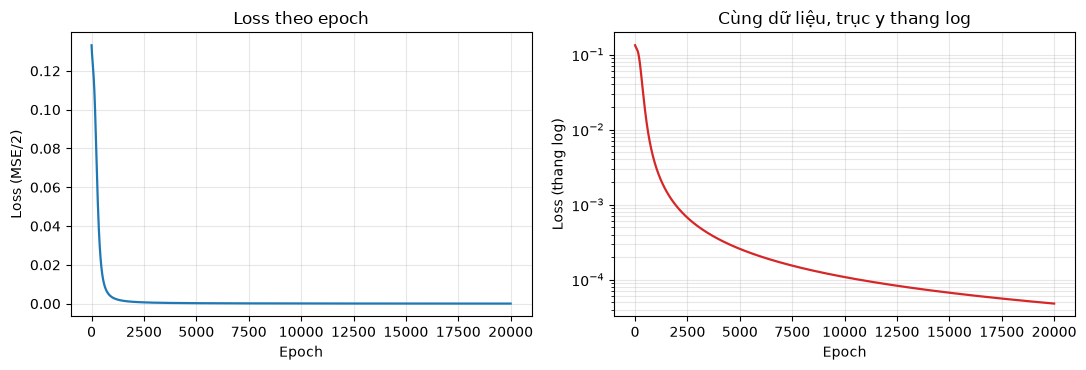

,x1_xa,x2_cao_diem,x3_mua,y_nhan,xac_suat_tre,canh_bao (nguong 0.5),dung?
0,0,0,0,0,0.0004,0,✔
1,0,1,0,0,0.0110,0,✔
2,1,0,0,0,0.0111,0,✔
3,1,1,0,1,0.9884,1,✔
4,0,0,1,0,0.0111,0,✔
5,0,1,1,1,0.9885,1,✔
6,1,0,1,1,0.9886,1,✔
7,1,1,1,1,0.9986,1,✔


Accuracy = 1.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(kq["loss"], lw=1.6)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (MSE/2)")
axes[0].set_title("Loss theo epoch"); axes[0].grid(alpha=0.3)
axes[1].semilogy(kq["loss"], lw=1.6, c="#d62728")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss (thang log)")
axes[1].set_title("Cùng dữ liệu, trục y thang log"); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

bang_kq = pd.DataFrame({
    "x1_xa": X[:, 0].astype(int),
    "x2_cao_diem": X[:, 1].astype(int),
    "x3_mua": X[:, 2].astype(int),
    "y_nhan": y[:, 0].astype(int),
    "xac_suat_tre": kq["y_hat"][:, 0].round(4),
    "canh_bao (nguong 0.5)": (kq["y_hat"][:, 0] >= 0.5).astype(int),
})
bang_kq["dung?"] = np.where(bang_kq["canh_bao (nguong 0.5)"] == bang_kq["y_nhan"], "✔", "✘")
display(bang_kq)

acc = (bang_kq["canh_bao (nguong 0.5)"] == bang_kq["y_nhan"]).mean()
print("Accuracy =", acc)
assert acc == 1.0

MLP phân loại đúng cả 8 tình huống. Nhưng nhớ kết luận ở phần 2: **Perceptron một tầng
cũng làm được điều này.** Giá trị của phần 9 không phải là "MLP mạnh hơn" mà là ta đã chạy
đúng thuật toán backpropagation trên một bài toán 3 đầu vào và kiểm tra được kết quả.

## 10. Tầng ẩn có thật sự học "xa ∧ cao điểm" không?

Tài liệu gợi ý một cách diễn giải rất hấp dẫn:

- $h_1$ học tổ hợp "xa **và** cao điểm"
- $h_2$ học tổ hợp "xa **và** mưa"
- $h_3$ học tổ hợp "cao điểm **và** mưa"

Tài liệu cũng đã cẩn thận ghi chú rằng *"các nơ-ron ẩn không bắt buộc học đúng những khái
niệm đã được đặt tên"*. Ta kiểm chứng xem thực tế mạng học ra cái gì, bằng cách dò
activation của tầng ẩn so với một danh sách hàm logic có tên.

In [15]:
x1b, x2b, x3b = X[:, 0].astype(bool), X[:, 1].astype(bool), X[:, 2].astype(bool)
dem = X.sum(axis=1)

cac_ham = {
    "FALSE": np.zeros(8, bool),                 "TRUE": np.ones(8, bool),
    "xa": x1b,                                  "NOT xa": ~x1b,
    "cao_diem": x2b,                            "NOT cao_diem": ~x2b,
    "mua": x3b,                                 "NOT mua": ~x3b,
    "xa AND cao_diem": x1b & x2b,               "xa AND mua": x1b & x3b,
    "cao_diem AND mua": x2b & x3b,              "xa OR cao_diem": x1b | x2b,
    "xa OR mua": x1b | x3b,                     "cao_diem OR mua": x2b | x3b,
    "OR cả ba": x1b | x2b | x3b,                "AND cả ba": x1b & x2b & x3b,
    "MAJORITY (đếm >= 2)": dem >= 2,            "NOT MAJORITY (đếm <= 1)": dem <= 1,
    "đếm >= 1": dem >= 1,                       "đếm == 0": dem == 0,
    "đếm == 3": dem == 3,                       "đếm <= 2": dem <= 2,
    "đếm đúng 2": dem == 2,                     "đếm lẻ (parity)": (dem % 2) == 1,
}


def doan_ham(vector_activation):
    lam_tron = vector_activation.round(0).astype(bool)
    ten = [k for k, v in cac_ham.items() if np.array_equal(lam_tron, v)]
    return ten[0] if ten else "không khớp hàm nào trong danh sách"


a1_hoc = kq["a1"]
bang_an = pd.DataFrame({
    "xa": X[:, 0].astype(int), "cao_điểm": X[:, 1].astype(int), "mưa": X[:, 2].astype(int),
    "đếm": dem.astype(int),
    "h1": a1_hoc[:, 0].round(3), "h2": a1_hoc[:, 1].round(3), "h3": a1_hoc[:, 2].round(3),
    "xác_suất_trễ": kq["y_hat"][:, 0].round(3),
    "y_nhãn": y[:, 0].astype(int),
})
display(bang_an)

for j in range(3):
    print(f"h{j+1} (làm tròn) ~ {doan_ham(a1_hoc[:, j])}")

print("\nW1 (dòng = input, cột = nơ-ron ẩn):")
display(pd.DataFrame(np.round(kq["W1"], 2),
                     index=["xa", "cao_diem", "mua"], columns=["h1", "h2", "h3"]))
print("b1 =", np.round(kq["b1"].ravel(), 2))
print("W2 =", np.round(kq["W2"].ravel(), 2), "| b2 =", np.round(kq["b2"].ravel(), 2))

,xa,cao_điểm,mưa,đếm,h1,h2,h3,xác_suất_trễ,y_nhãn
0,0,0,0,0,0.541,0.991,0.040,0.000,0
1,0,1,0,1,0.411,0.789,0.302,0.011,0
2,1,0,0,1,0.364,0.802,0.312,0.011,0
3,1,1,0,2,0.253,0.125,0.825,0.988,1
4,0,0,1,1,0.332,0.801,0.306,0.011,0
5,0,1,1,2,0.228,0.125,0.820,0.988,1
6,1,0,1,2,0.195,0.133,0.827,0.989,1
7,1,1,1,3,0.125,0.005,0.980,0.999,1


h1 (làm tròn) ~ đếm == 0
h2 (làm tròn) ~ NOT MAJORITY (đếm <= 1)
h3 (làm tròn) ~ MAJORITY (đếm >= 2)

W1 (dòng = input, cột = nơ-ron ẩn):


,h1,h2,h3
xa,-0.72,-3.26,2.39
cao_diem,-0.52,-3.34,2.34
mua,-0.86,-3.27,2.36


b1 = [ 0.16  4.66 -3.18]
W2 = [-1.18 -8.35  6.15] | b2 = [0.72]


Kết quả khác hẳn cách diễn giải được đặt tên trước:

**Không nơ-ron nào học một cặp AND cụ thể.** Thay vào đó, hãy nhìn ma trận `W1`: trong mỗi
cột, ba trọng số **gần bằng nhau**. Một nơ-ron có ba trọng số bằng nhau thì đầu ra của nó
chỉ phụ thuộc vào **tổng** $x_1+x_2+x_3$, tức là *số* yếu tố bất lợi — chứ không phân biệt
đó là yếu tố nào.

Cụ thể, cả ba nơ-ron đều học một **ngưỡng trên số đếm**, không nơ-ron nào quan tâm
*yếu tố nào* đang bất lợi:

- $h_3 \approx$ **MAJORITY**, tức "đếm ≥ 2" — chính là bài toán cần giải.
- $h_2 \approx$ **NOT MAJORITY**, tức "đếm ≤ 1" — bản phủ định của $h_3$.
- $h_1 \approx$ "đếm == 0" — một ngưỡng chặt hơn, và tầng ra gần như bỏ qua nó
  (trọng số −1.18, nhỏ hơn nhiều so với −8.35 và +6.15 của hai nơ-ron kia).

Tầng ra gộp lại bằng trọng số trái dấu: cộng $h_3$, trừ $h_2$.

Vì sao mạng lại chọn cách này thay vì học ba cặp AND? Vì **nó đúng hơn và đơn giản hơn**.
Nhãn là hàm đối xứng theo ba đầu vào, nên nghiệm tối ưu cũng đối xứng. Học riêng ba cặp AND
là cách *phức tạp hơn* để biểu diễn cùng một hàm, và gradient descent không có lý do gì đi
đường vòng đó.

Bài học chung, rất đáng nhấn mạnh với sinh viên:

> Cách diễn giải "nơ-ron này học khái niệm kia" thường là câu chuyện **chúng ta gán vào sau
> khi huấn luyện**, không phải điều mạng bị buộc phải làm. Muốn biết tầng ẩn học gì, phải
> **kiểm tra activation**, không phải đoán từ tên khái niệm.

Đây cũng là lý do lĩnh vực *interpretability* (khả năng giải thích mô hình) tồn tại như một
ngành nghiên cứu riêng.

## 11. Khi nào **thật sự** cần tầng ẩn?

Ở phần 2 ta thấy bộ dữ liệu gốc tách được tuyến tính. Vậy hãy dựng một biến thể giao hàng
mà một Perceptron **không** giải được, để thấy tầng ẩn phát huy tác dụng ở đâu.

**Quy tắc nghiệp vụ mới:** khi **cả ba** điều kiện đều bất lợi, hệ thống tự động chuyển đơn
sang chế độ *"giao chậm có thông báo trước"* — khách đã được báo và đồng ý thời gian mới,
nên đơn **không bị tính là trễ**. Chỉ khi có **đúng hai** điều kiện bất lợi thì đơn mới bị
trễ ngoài dự kiến: đủ xấu để chậm, nhưng chưa đủ xấu để hệ thống kịp cảnh báo.

$$
y_{\text{mới}} = 1 \iff x_1 + x_2 + x_3 = 2
$$

Quan hệ này **không đơn điệu**: thêm một yếu tố bất lợi (từ 2 lên 3) lại làm nhãn **giảm**
từ 1 về 0. Đúng kiểu phi tuyến mà XOR có.

In [16]:
y_bien_the = (X.sum(axis=1) == 2).astype(float).reshape(-1, 1)

display(pd.DataFrame({
    "xa": X[:, 0].astype(int), "cao_điểm": X[:, 1].astype(int), "mưa": X[:, 2].astype(int),
    "đếm": X.sum(axis=1).astype(int),
    "y_gốc (đếm >= 2)": y[:, 0].astype(int),
    "y_biến_thể (đếm == 2)": y_bien_the[:, 0].astype(int),
}))

print("Perceptron một tầng trên biến thể:")
for seed in range(5):
    *_, acc = perceptron_hoc(X, y_bien_the, so_epoch=500, seed=seed)
    print(f"  seed={seed} | accuracy = {acc:.3f}")

,xa,cao_điểm,mưa,đếm,y_gốc (đếm >= 2),y_biến_thể (đếm == 2)
0,0,0,0,0,0,0
1,0,1,0,1,0,0
2,1,0,0,1,0,0
3,1,1,0,2,1,1
4,0,0,1,1,0,0
5,0,1,1,2,1,1
6,1,0,1,2,1,1
7,1,1,1,3,1,0


Perceptron một tầng trên biến thể:
  seed=0 | accuracy = 0.500
  seed=1 | accuracy = 0.500
  seed=2 | accuracy = 0.250
  seed=3 | accuracy = 0.500
  seed=4 | accuracy = 0.500


Perceptron chỉ đạt 0.25–0.50 (và dù chọn lượt tốt nhất trong quá trình học cũng không
quá 0.75) — **không bao giờ** đạt 1.00, đúng như dự đoán lý thuyết. So sánh với bộ dữ liệu
gốc ở phần 2, nơi cùng hàm này đạt 1.00 ngay: chỉ đổi nhãn của **một** dòng (từ 1 xuống 0 ở
mẫu `(1,1,1)`) là bài toán chuyển từ dễ sang bất khả thi với mô hình tuyến tính.

Chứng minh hình học ngắn gọn: tâm của ba điểm dương $(1,1,0), (0,1,1), (1,0,1)$ là
$(\tfrac23,\tfrac23,\tfrac23)$. Nhưng điểm này cũng nằm trên đoạn nối hai điểm **âm**
$(0,0,0)$ và $(1,1,1)$ (với tỉ lệ $\tfrac13$ và $\tfrac23$). Bao lồi của hai lớp giao nhau,
nên không có siêu phẳng nào tách được chúng.

Giờ thử MLP trên cùng dữ liệu.

In [17]:
kq_bt = huan_luyen_mlp(X, y_bien_the, so_an=4, eta=1.0, so_epoch=40000,
                       seed=42, ghi_log_moi=10000)

bang_bt = pd.DataFrame({
    "xa": X[:, 0].astype(int), "cao_điểm": X[:, 1].astype(int), "mưa": X[:, 2].astype(int),
    "đếm": X.sum(axis=1).astype(int),
    "y_nhãn": y_bien_the[:, 0].astype(int),
    "dự_đoán": kq_bt["y_hat"][:, 0].round(3),
    "quyết_định": (kq_bt["y_hat"][:, 0] >= 0.5).astype(int),
})
bang_bt["đúng?"] = np.where(bang_bt["quyết_định"] == bang_bt["y_nhãn"], "✔", "✘")
display(bang_bt)

acc_bt = (bang_bt["quyết_định"] == bang_bt["y_nhãn"]).mean()
print(f"Loss cuối = {kq_bt['loss'][-1]:.6f} | Accuracy MLP = {acc_bt}")
assert acc_bt == 1.0, "MLP phải giải được biến thể phi tuyến"

for j in range(kq_bt["a1"].shape[1]):
    print(f"h{j+1} ~ {doan_ham(kq_bt['a1'][:, j])}")

Epoch      0 | Loss = 0.131640
Epoch  10000 | Loss = 0.000484
Epoch  20000 | Loss = 0.000153
Epoch  30000 | Loss = 0.000089


,xa,cao_điểm,mưa,đếm,y_nhãn,dự_đoán,quyết_định,đúng?
0,0,0,0,0,0,0.000,0,✔
1,0,1,0,1,0,0.006,0,✔
2,1,0,0,1,0,0.006,0,✔
3,1,1,0,2,1,0.987,1,✔
4,0,0,1,1,0,0.006,0,✔
5,0,1,1,2,1,0.987,1,✔
6,1,0,1,2,1,0.987,1,✔
7,1,1,1,3,0,0.019,0,✔


Loss cuối = 0.000062 | Accuracy MLP = 1.0
h1 ~ NOT MAJORITY (đếm <= 1)
h2 ~ NOT MAJORITY (đếm <= 1)
h3 ~ MAJORITY (đếm >= 2)
h4 ~ AND cả ba


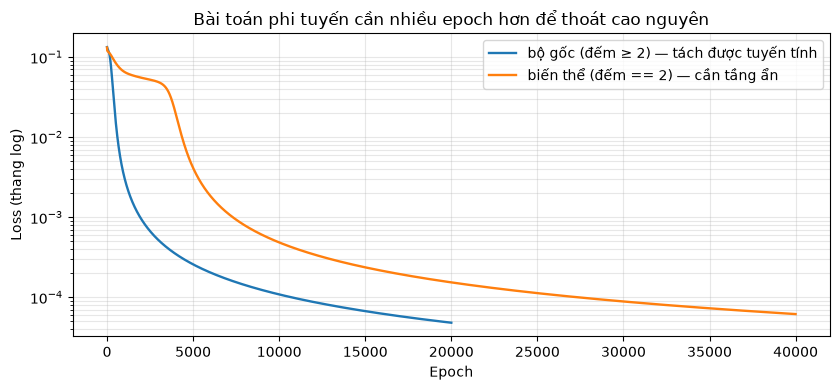

In [18]:
fig, ax = plt.subplots(figsize=(8.5, 4)) 
ax.semilogy(kq["loss"], lw=1.7, label="bộ gốc (đếm ≥ 2) — tách được tuyến tính")
ax.semilogy(kq_bt["loss"], lw=1.7, label="biến thể (đếm == 2) — cần tầng ẩn")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (thang log)")
ax.set_title("Bài toán phi tuyến cần nhiều epoch hơn để thoát cao nguyên")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.tight_layout(); plt.show()

MLP giải được biến thể với accuracy 1.00, còn Perceptron thì không. **Đây mới là trường hợp
tầng ẩn thực sự cần thiết.**

So sánh hai đường loss cũng cho thấy đặc trưng của bài toán phi tuyến: đường của biến thể
có **cao nguyên** dài ở đầu (mạng dự đoán xấp xỉ hằng số cho mọi mẫu) rồi mới tụt, và cần
nhiều epoch hơn hẳn. Bài toán tuyến tính thì giảm đều ngay từ đầu.

Tổng kết hai bộ dữ liệu:

| | Bộ gốc (đếm ≥ 2) | Biến thể (đếm == 2) |
|---|---|---|
| Quan hệ | đơn điệu, tách được tuyến tính | không đơn điệu, phi tuyến |
| Perceptron 1 tầng | **1.00** | 0.625 – 0.75 |
| MLP có tầng ẩn | 1.00 | **1.00** |
| Có cần tầng ẩn? | không | **có** |

Câu hỏi nên đặt cho sinh viên: *trước khi chọn mô hình, làm sao biết bài toán của mình
thuộc loại nào?* Câu trả lời thực tế: thử mô hình tuyến tính trước, xem nó sai ở đâu, rồi
mới quyết định có cần mô hình phi tuyến hay không.

## 12. Thí nghiệm: learning rate và số nơ-ron ẩn

Thử trên **biến thể phi tuyến** vì đó mới là bài toán thực sự thử thách thuật toán.

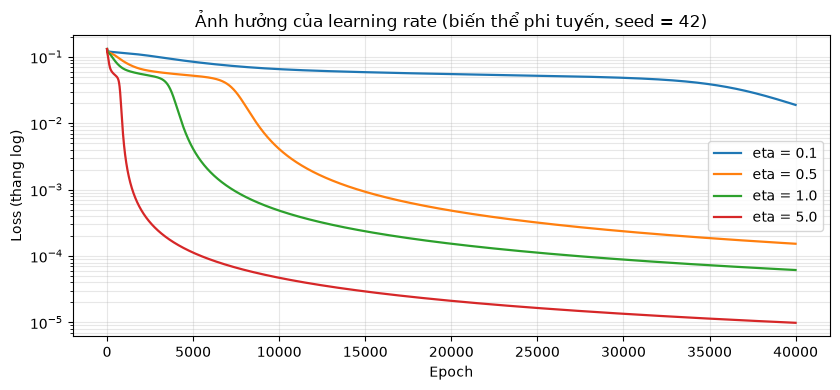

,eta,loss cuối,epoch đạt loss < 0.01,accuracy
0,0.1,0.018921,NaN,1.0
1,0.5,0.000153,8702.0,1.0
2,1.0,0.000062,4356.0,1.0
3,5.0,0.000010,882.0,1.0


In [19]:
cac_eta = [0.1, 0.5, 1.0, 5.0]
ket_qua = {}

fig, ax = plt.subplots(figsize=(8.5, 4))
for e in cac_eta:
    r = huan_luyen_mlp(X, y_bien_the, so_an=4, eta=e, so_epoch=40000,
                       seed=42, ghi_log_moi=0)
    ket_qua[e] = r
    ax.semilogy(r["loss"], lw=1.6, label=f"eta = {e}")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (thang log)")
ax.set_title("Ảnh hưởng của learning rate (biến thể phi tuyến, seed = 42)")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.tight_layout(); plt.show()

display(pd.DataFrame([{
    "eta": e,
    "loss cuối": r["loss"][-1],
    "epoch đạt loss < 0.01": (int(np.argmax(r["loss"] < 0.01))
                              if (r["loss"] < 0.01).any() else None),
    "accuracy": ((r["y_hat"][:, 0] >= 0.5).astype(float)
                 == y_bien_the[:, 0]).mean().item(),
} for e, r in ket_qua.items()]))

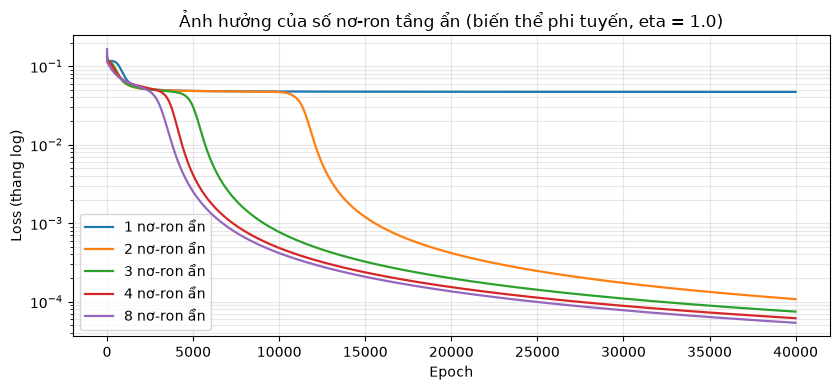

,số nơ-ron ẩn,số tham số,loss cuối,accuracy
0,1,6,0.047033,0.875
1,2,11,0.000108,1.000
2,3,16,0.000075,1.000
3,4,21,0.000062,1.000
4,8,41,0.000054,1.000


In [20]:
dong = []
fig, ax = plt.subplots(figsize=(8.5, 4))
for h in [1, 2, 3, 4, 8]:
    r = huan_luyen_mlp(X, y_bien_the, so_an=h, eta=1.0, so_epoch=40000,
                       seed=42, ghi_log_moi=0)
    ax.semilogy(r["loss"], lw=1.6, label=f"{h} nơ-ron ẩn")
    dong.append({
        "số nơ-ron ẩn": h,
        "số tham số": 3 * h + h + h + 1,
        "loss cuối": r["loss"][-1],
        "accuracy": ((r["y_hat"][:, 0] >= 0.5).astype(float)
                     == y_bien_the[:, 0]).mean().item(),
    })
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (thang log)")
ax.set_title("Ảnh hưởng của số nơ-ron tầng ẩn (biến thể phi tuyến, eta = 1.0)")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.tight_layout(); plt.show()

display(pd.DataFrame(dong))

Đọc hai bảng trên khi chạy:

- **Learning rate nhỏ** (`0.1`) *vẫn* phân loại đúng cả 8 mẫu, nhưng loss cuối chỉ giảm
  tới 0.019 và không bao giờ xuống dưới 0.01 trong 40000 epoch. Nghĩa là mô hình đã đúng về
  quyết định nhưng còn rất "lưỡng lự" — các dự đoán chưa dứt khoát về 0 và 1. Đây là lý do
  không nên chỉ nhìn accuracy mà bỏ qua loss.
- `0.5` và `1.0` hoạt động ổn định (đạt loss < 0.01 sau ~8700 và ~4400 epoch).
- `5.0` hội tụ nhanh nhất (~880 epoch) ở bài toán 8 mẫu này. Đừng suy ra "càng lớn càng
  tốt": với dữ liệu thật, learning rate lớn thường làm loss dao động hoặc phân kỳ (bài tập 3).
- **Một nơ-ron ẩn** không đủ: mạng `3 → 1 → 1` chỉ tạo được một ranh giới tuyến tính nên
  đứng lại ở accuracy 0.875 (sai 1/8 mẫu) và loss 0.047. Từ **2 nơ-ron ẩn** trở lên là giải
  được; thêm nữa thì hội tụ nhanh hơn chút ít nhưng không cần thiết.

## 13. Mở rộng sang dữ liệu liên tục

Tám tình huống nhị phân chỉ để giảng nguyên lý. Một hệ thống thật dùng đặc trưng liên tục:

| Đặc trưng | Kiểu | Đơn vị |
|---|---|---|
| Khoảng cách | liên tục | km |
| Mức ùn tắc | liên tục | điểm 0–1 |
| Lượng mưa | liên tục | mm/giờ |
| Thời gian chuẩn bị món | liên tục | phút |
| Số đơn tài xế đang giữ | rời rạc | số đơn |
| Nhãn: có trễ không | nhị phân | 0/1 |

Phần này mô phỏng 1200 đơn hàng, chia **train/test**, huấn luyện MLP, rồi đánh giá bằng
**confusion matrix, precision, recall** và bàn về việc **chọn ngưỡng cảnh báo** — những
việc bắt buộc phải làm trước khi đưa mô hình vào vận hành.

> Dữ liệu là mô phỏng, dùng để học quy trình. Hệ số trong hàm sinh dữ liệu không phải tham
> số vận hành của bất kỳ nền tảng giao hàng nào.

In [21]:
rng = np.random.default_rng(7)
n_don = 1200

# --- Sinh đặc trưng ---
khoang_cach = rng.uniform(0.5, 12.0, n_don)          # km
un_tac = rng.uniform(0.0, 1.0, n_don)                # điểm 0-1
luong_mua = rng.choice([0, 0, 0, 2, 8, 18], n_don)    # mm/giờ, phần lớn không mưa
thoi_gian_mon = rng.uniform(3.0, 25.0, n_don)         # phút
so_don_dang_giu = rng.integers(1, 4, n_don)           # 1-3 đơn

# --- Quy tắc sinh thời gian giao thực tế (có TƯƠNG TÁC: km nhân với ùn tắc & mưa) ---
thoi_gian_thuc = (8.0
                  + 3.0 * khoang_cach * (1 + 0.9 * un_tac + 0.02 * luong_mua)
                  + thoi_gian_mon
                  + 3.0 * so_don_dang_giu
                  + rng.normal(0, 4.0, n_don))        # nhiễu: yếu tố không quan sát được

thoi_gian_cam_ket = 30.0 + 4.65 * khoang_cach         # app cam kết với khách
bi_tre = (thoi_gian_thuc > thoi_gian_cam_ket).astype(float)

Xc = np.c_[khoang_cach, un_tac, luong_mua, thoi_gian_mon, so_don_dang_giu]
yc = bi_tre.reshape(-1, 1)
ten_dac_trung = ["khoang_cach_km", "un_tac", "luong_mua_mm", "thoi_gian_mon_phut", "so_don"]

print("Số đơn:", n_don, "| Tỉ lệ trễ:", f"{bi_tre.mean()*100:.1f}%")
display(pd.DataFrame(Xc, columns=ten_dac_trung).describe().round(2))

Số đơn: 1200 | Tỉ lệ trễ: 41.5%


,khoang_cach_km,un_tac,luong_mua_mm,thoi_gian_mon_phut,so_don
count,1200.00,1200.00,1200.00,1200.00,1200.00
mean,6.20,0.51,4.61,13.72,1.97
std,3.32,0.29,6.59,6.28,0.82
min,0.54,0.00,0.00,3.02,1.00
25%,3.34,0.26,0.00,8.44,1.00
50%,6.21,0.50,0.00,13.42,2.00
75%,9.14,0.76,8.00,19.00,3.00
max,11.99,1.00,18.00,24.98,3.00


Điểm quan trọng trong hàm sinh dữ liệu: khoảng cách được **nhân** với mức ùn tắc và lượng
mưa, chứ không phải cộng. Nghĩa là mưa làm chậm *nhiều hơn* trên tuyến đường dài — đúng
một **tương tác** (*interaction*) giữa các đặc trưng. Đây là loại quan hệ mà tầng ẩn có thể
học còn mô hình tuyến tính thì không biểu diễn trực tiếp được.

Tiếp theo là hai bước bắt buộc và rất dễ làm sai: **chia train/test** và **chuẩn hoá**.

In [22]:
# --- Chia train/test ---
thu_tu = rng.permutation(n_don)
n_train = int(0.7 * n_don)
idx_train, idx_test = thu_tu[:n_train], thu_tu[n_train:]

# --- Chuẩn hoá: TÍNH mu/sigma CHỈ TRÊN TRAIN rồi áp cho test ---
# Nếu tính trên toàn bộ dữ liệu thì thông tin của test bị rò rỉ sang train (data leakage)
mu = Xc[idx_train].mean(axis=0)
sigma = Xc[idx_train].std(axis=0)

X_train = (Xc[idx_train] - mu) / sigma
X_test = (Xc[idx_test] - mu) / sigma
y_train, y_test = yc[idx_train], yc[idx_test]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Tỉ lệ trễ — train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%")
print("\nSau chuẩn hoá, train có mean ~ 0 và std ~ 1:")
display(pd.DataFrame({"mean": X_train.mean(axis=0).round(3),
                      "std": X_train.std(axis=0).round(3)}, index=ten_dac_trung))

Train: (840, 5) | Test: (360, 5)
Tỉ lệ trễ — train: 41.7% | test: 41.1%

Sau chuẩn hoá, train có mean ~ 0 và std ~ 1:


,mean,std
khoang_cach_km,0.0,1.0
un_tac,-0.0,1.0
luong_mua_mm,0.0,1.0
thoi_gian_mon_phut,-0.0,1.0
so_don,-0.0,1.0


Vì sao phải chuẩn hoá? Khoảng cách chạy 0.5–12, lượng mưa 0–18, thời gian món 3–25. Nếu
không đưa về cùng thang đo, các đặc trưng có giá trị lớn sẽ áp đảo tổng có trọng số, và
gradient của các đặc trưng còn lại bị lấn át — mạng học rất chậm.

Ở đây ta cũng đổi loss sang **binary cross-entropy (BCE)** vì đó là lựa chọn chuẩn cho phân
loại hai lớp với sigmoid:

$$
L = -\frac{1}{m}\sum\Bigl[y\ln\hat y + (1-y)\ln(1-\hat y)\Bigr]
$$

Điểm đẹp của BCE: khi ghép với sigmoid ở tầng ra, hệ số $\hat y(1-\hat y)$ **bị triệt tiêu**
và delta tầng ra rút gọn thành

$$
\delta^{(2)} = \hat y - y
$$

Gọn hơn MSE, và quan trọng hơn: **không còn bị sigmoid bão hoà làm gradient tiêu biến** ở
tầng ra. Toàn bộ phần backward tầng ẩn giữ nguyên không đổi một dòng.

BCE train cuối = 0.2408 | BCE test cuối = 0.2693


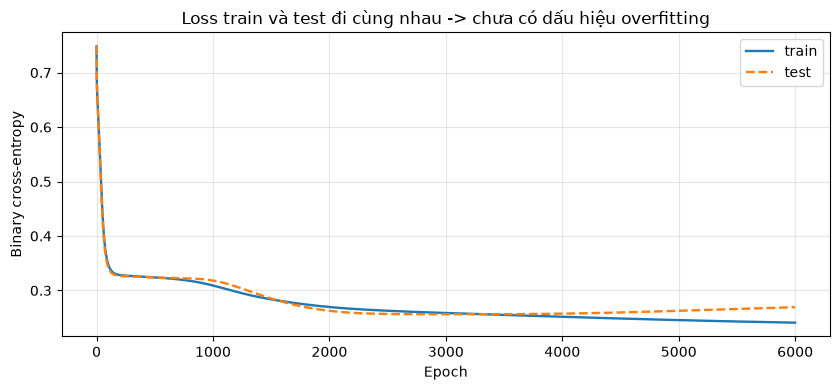

In [23]:
def huan_luyen_bce(X, y, so_an=8, eta=0.5, so_epoch=6000, seed=42, X_val=None, y_val=None):
    # MLP (n -> so_an -> 1), loss = BCE, full-batch. delta2 rút gọn = y_hat - y
    rng_local = np.random.default_rng(seed)
    m, n_in = X.shape

    # Khởi tạo kiểu Xavier/Glorot: chia cho căn số đầu vào, tránh bão hoà ngay từ đầu
    W1 = rng_local.normal(0, 1 / np.sqrt(n_in), size=(n_in, so_an))
    b1 = np.zeros((1, so_an))
    W2 = rng_local.normal(0, 1 / np.sqrt(so_an), size=(so_an, 1))
    b2 = np.zeros((1, 1))

    lich_su, lich_su_val = [], []

    for _ in range(so_epoch):
        # FORWARD
        a1 = sigmoid(X @ W1 + b1)
        y_hat = np.clip(sigmoid(a1 @ W2 + b2), 1e-12, 1 - 1e-12)
        lich_su.append(float(-np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))))

        if X_val is not None:
            a1v = sigmoid(X_val @ W1 + b1)
            yv = np.clip(sigmoid(a1v @ W2 + b2), 1e-12, 1 - 1e-12)
            lich_su_val.append(
                float(-np.mean(y_val * np.log(yv) + (1 - y_val) * np.log(1 - yv))))

        # BACKWARD — chỉ dòng delta2 khác so với bản MSE
        delta2 = (y_hat - y) / m
        dW2 = a1.T @ delta2
        db2 = delta2.sum(axis=0, keepdims=True)
        delta1 = (delta2 @ W2.T) * a1 * (1 - a1)
        dW1 = X.T @ delta1
        db1 = delta1.sum(axis=0, keepdims=True)

        # UPDATE
        W2 -= eta * dW2; b2 -= eta * db2
        W1 -= eta * dW1; b1 -= eta * db1

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2,
            "loss": np.array(lich_su), "loss_val": np.array(lich_su_val)}


def du_doan(X, ts):
    return sigmoid(sigmoid(X @ ts["W1"] + ts["b1"]) @ ts["W2"] + ts["b2"])


mo_hinh = huan_luyen_bce(X_train, y_train, so_an=8, eta=0.5, so_epoch=6000,
                         seed=42, X_val=X_test, y_val=y_test)
print(f"BCE train cuối = {mo_hinh['loss'][-1]:.4f} | BCE test cuối = {mo_hinh['loss_val'][-1]:.4f}")

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(mo_hinh["loss"], lw=1.7, label="train")
ax.plot(mo_hinh["loss_val"], lw=1.7, ls="--", label="test")
ax.set_xlabel("Epoch"); ax.set_ylabel("Binary cross-entropy")
ax.set_title("Loss train và test đi cùng nhau -> chưa có dấu hiệu overfitting")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

In [24]:
def danh_gia(y_that, diem, nguong=0.5):
    du_doan_nhan = (diem >= nguong).astype(float)
    tp = int(((du_doan_nhan == 1) & (y_that == 1)).sum())
    tn = int(((du_doan_nhan == 0) & (y_that == 0)).sum())
    fp = int(((du_doan_nhan == 1) & (y_that == 0)).sum())
    fn = int(((du_doan_nhan == 0) & (y_that == 1)).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "accuracy": (tp + tn) / len(y_that),
            "precision": precision, "recall": recall, "f1": f1}


diem_train = du_doan(X_train, mo_hinh)[:, 0]
diem_test = du_doan(X_test, mo_hinh)[:, 0]

kq_train = danh_gia(y_train[:, 0], diem_train)
kq_test = danh_gia(y_test[:, 0], diem_test)

display(pd.DataFrame({"train": kq_train, "test": kq_test}).T.round(4))

print("Confusion matrix trên TEST (ngưỡng 0.5):")
display(pd.DataFrame(
    [[kq_test["TN"], kq_test["FP"]], [kq_test["FN"], kq_test["TP"]]],
    index=["Thực tế: đúng giờ", "Thực tế: TRỄ"],
    columns=["Dự đoán: đúng giờ", "Dự đoán: TRỄ"]))

,TP,FP,FN,TN,accuracy,precision,recall,f1
train,306.0,44.0,44.0,446.0,0.8952,0.8743,0.8743,0.8743
test,126.0,22.0,22.0,190.0,0.8778,0.8514,0.8514,0.8514


Confusion matrix trên TEST (ngưỡng 0.5):


,Dự đoán: đúng giờ,Dự đoán: TRỄ
Thực tế: đúng giờ,190,22
Thực tế: TRỄ,22,126


Accuracy trên test xấp xỉ accuracy trên train, nên mô hình **không bị overfitting**. Nhưng
accuracy chưa đủ để ra quyết định vận hành — phải đọc hai loại lỗi riêng:

- **FP (false positive)** — cảnh báo trễ nhưng đơn vẫn đúng giờ. Hệ quả: tốn chi phí xử lý
  không cần thiết (tặng voucher, gọi điện xin lỗi, điều thêm tài xế).
- **FN (false negative)** — **không** cảnh báo nhưng đơn bị trễ. Hệ quả: khách bất ngờ, mất
  uy tín, có thể mất khách.

Hai loại lỗi này **không tương đương về giá trị kinh doanh**, nên ngưỡng 0.5 không có gì
đặc biệt. Ngưỡng là một quyết định nghiệp vụ, không phải hằng số toán học.

,ngưỡng,TP,FP,FN,TN,accuracy,precision,recall,f1
0,0.2,143,48,5,164,0.8528,0.7487,0.9662,0.8437
1,0.3,137,34,11,178,0.8750,0.8012,0.9257,0.8589
2,0.4,133,26,15,186,0.8861,0.8365,0.8986,0.8664
3,0.5,126,22,22,190,0.8778,0.8514,0.8514,0.8514
4,0.6,122,20,26,192,0.8722,0.8592,0.8243,0.8414
5,0.7,112,14,36,198,0.8611,0.8889,0.7568,0.8175
6,0.8,96,10,52,202,0.8278,0.9057,0.6486,0.7559


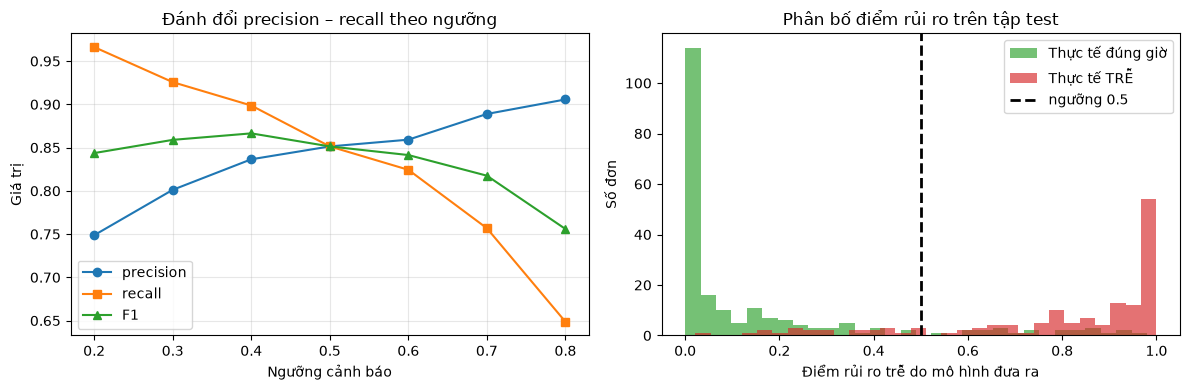

In [25]:
cac_nguong = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
bang_nguong = pd.DataFrame([
    {"ngưỡng": th, **{k: v for k, v in danh_gia(y_test[:, 0], diem_test, th).items()}}
    for th in cac_nguong
])
display(bang_nguong.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(bang_nguong["ngưỡng"], bang_nguong["precision"], "o-", label="precision")
axes[0].plot(bang_nguong["ngưỡng"], bang_nguong["recall"], "s-", label="recall")
axes[0].plot(bang_nguong["ngưỡng"], bang_nguong["f1"], "^-", label="F1")
axes[0].set_xlabel("Ngưỡng cảnh báo"); axes[0].set_ylabel("Giá trị")
axes[0].set_title("Đánh đổi precision – recall theo ngưỡng")
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].hist(diem_test[y_test[:, 0] == 0], bins=30, alpha=0.65,
             label="Thực tế đúng giờ", color="#2ca02c")
axes[1].hist(diem_test[y_test[:, 0] == 1], bins=30, alpha=0.65,
             label="Thực tế TRỄ", color="#d62728")
axes[1].axvline(0.5, color="black", ls="--", lw=2, label="ngưỡng 0.5")
axes[1].set_xlabel("Điểm rủi ro trễ do mô hình đưa ra"); axes[1].set_ylabel("Số đơn")
axes[1].set_title("Phân bố điểm rủi ro trên tập test")
axes[1].legend()
plt.tight_layout(); plt.show()

Bảng và hình cho thấy quy luật đánh đổi: **hạ** ngưỡng thì recall tăng (bắt được nhiều đơn
trễ hơn) nhưng precision giảm (báo động giả nhiều hơn); **nâng** ngưỡng thì ngược lại. Không
có ngưỡng nào tốt nhất về mọi mặt.

Cách chọn trong thực tế là quy ra chi phí: nếu một FN (khách chờ mà không được báo) tốn gấp
3 lần một FP (tặng voucher không cần thiết), thì nên hạ ngưỡng xuống dưới 0.5 để ưu tiên
recall. Hai biểu đồ chồng nhau ở hình phải cũng cho thấy giới hạn của mô hình: vùng hai phân
bố giao nhau là những đơn hàng mà các đặc trưng hiện có **không đủ** để phân biệt — muốn
tốt hơn thì phải thêm đặc trưng, không phải chỉnh ngưỡng.

In [26]:
# So sánh MLP với một mô hình TUYẾN TÍNH (logistic regression) trên cùng dữ liệu
def huan_luyen_logistic(X, y, eta=0.5, so_epoch=6000):
    w = np.zeros((X.shape[1], 1))
    b = 0.0
    m = len(X)
    for _ in range(so_epoch):
        p = np.clip(sigmoid(X @ w + b), 1e-12, 1 - 1e-12)
        d = (p - y) / m
        w -= eta * (X.T @ d)
        b -= eta * float(d.sum())
    return w, b


w_lg, b_lg = huan_luyen_logistic(X_train, y_train)
diem_lg = sigmoid(X_test @ w_lg + b_lg)[:, 0]
kq_lg = danh_gia(y_test[:, 0], diem_lg)

display(pd.DataFrame({
    "Logistic (tuyến tính, 6 tham số)": kq_lg,
    "MLP (8 nơ-ron ẩn, 57 tham số)": kq_test,
}).T.round(4))

print("Trọng số logistic (đã chuẩn hoá nên so sánh được độ lớn):")
display(pd.Series(w_lg[:, 0], index=ten_dac_trung).round(3).sort_values(key=abs, ascending=False))

,TP,FP,FN,TN,accuracy,precision,recall,f1
"Logistic (tuyến tính, 6 tham số)",117.0,20.0,31.0,192.0,0.8583,0.8540,0.7905,0.8211
"MLP (8 nơ-ron ẩn, 57 tham số)",126.0,22.0,22.0,190.0,0.8778,0.8514,0.8514,0.8514


Trọng số logistic (đã chuẩn hoá nên so sánh được độ lớn):


thoi_gian_mon_phut    2.394
un_tac                1.632
so_don                1.024
luong_mua_mm          0.907
khoang_cach_km        0.021
dtype: float64

MLP hơn mô hình tuyến tính khoảng 2 điểm accuracy (0.878 so với 0.858), nhưng khoảng cách
rõ hơn ở **recall**: 0.851 so với 0.791 — MLP bỏ sót 22 đơn trễ, logistic bỏ sót 31 đơn. Với
bài toán cảnh báo, recall thường quan trọng hơn accuracy, nên mức chênh này có ý nghĩa thực.

Dù vậy, nó đổi lấy gần 10 lần số tham số. Kết quả nhất quán với bài học ở phần 2 và 11: dữ
liệu này **phần lớn** giải thích được bằng quan hệ cộng dồn, phần tương tác chỉ đóng góp
thêm một lượng vừa phải.

Lợi ích đi kèm của mô hình tuyến tính: trọng số đọc được trực tiếp. Vì các đặc trưng đã
chuẩn hoá cùng thang đo, độ lớn trọng số cho biết đặc trưng nào ảnh hưởng mạnh nhất — thông
tin rất có giá trị khi báo cáo cho bộ phận vận hành. MLP không cho bạn thứ đó miễn phí.

Bảng trọng số còn hé ra một điều dễ bị bỏ qua: **khoảng cách có trọng số gần bằng 0 (0.02)**,
trong khi trực giác nói nó phải là yếu tố quan trọng nhất. Nguyên nhân nằm trong cách sinh dữ
liệu: thời gian *cam kết* với khách cũng tăng theo khoảng cách (`30 + 4.65·km`), nên đi xa hơn
thì được cho thêm thời gian — hai tác động gần như triệt tiêu nhau. Yếu tố thật sự gây trễ là
những thứ **không** được tính vào cam kết: thời gian chuẩn bị món, mức ùn tắc, số đơn tài xế
đang giữ.

Đây là bài học về đặc trưng, không phải về mô hình: *nhãn đo độ trễ so với một cam kết, nên
đặc trưng nào đã nằm trong cam kết sẽ mất phần lớn sức dự báo.* Dạng nhận xét này chỉ có được
khi ta dừng lại đọc trọng số, thay vì chỉ nhìn accuracy.

> Kết luận nghề: dùng mô hình tuyến tính làm **baseline** bắt buộc. Chỉ chọn mạng nơ-ron khi
> nó thắng baseline đủ nhiều để bù cho việc mất khả năng giải thích.

## 14. Bài tập

**Bài 1 — Tính tay đơn hàng khác.** Lặp lại phần 4–7 cho đơn hàng **gần, không cao điểm, có
mưa**: $\mathbf{x} = [0,0,1]^\top$, nhãn $y = 0$. Dự đoán trước: những cột nào của
$\partial L/\partial\mathbf{W}^{(1)}$ sẽ bằng 0? Dấu của $\delta^{(2)}$ lần này là gì, và vì
sao khác dấu so với ví dụ trong bài?

**Bài 2 — Hoạt động nhóm (4 nhóm).** Mỗi nhóm nhận một tình huống, tự tính tay một lượt
forward + backward rồi dùng hàm `kiem_tra_mot_mau` dưới đây để đối chiếu:

| Nhóm | Tình huống | $\mathbf{x}$ | Nhãn theo quy tắc gốc |
|---|---|---|---|
| 1 | Gần, cao điểm, có mưa | $[0,1,1]$ | 1 |
| 2 | Xa, không cao điểm, có mưa | $[1,0,1]$ | 1 |
| 3 | Xa, cao điểm, không mưa | $[1,1,0]$ | 1 |
| 4 | Gần, không cao điểm, không mưa | $[0,0,0]$ | 0 |

Mỗi nhóm phải trả lời: trọng số nào có gradient bằng 0 và vì sao; dấu của $\delta^{(2)}$ nói
lên điều gì về hướng điều chỉnh.

**Bài 3 — Learning rate quá lớn.** Chạy `huan_luyen_mlp` với `eta = 50` và `eta = 200` trên
biến thể phi tuyến. Loss dao động hay phân kỳ? Vẽ loss curve minh chứng.

**Bài 4 — Thêm một đặc trưng.** Thêm $x_4$ = "món cần chuẩn bị lâu" vào bộ 8 mẫu (thành 16
tình huống), tự đặt quy tắc nhãn, rồi kiểm tra quy tắc mới có tách được tuyến tính không
bằng cách so Perceptron với MLP.

**Bài 5 — ReLU ở tầng ẩn.** Đổi activation tầng ẩn thành ReLU ($\max(0,z)$, đạo hàm là
`(z > 0)`), giữ sigmoid ở tầng ra. So sánh số epoch cần thiết trên biến thể phi tuyến.

**Bài 6 — Chọn ngưỡng theo chi phí.** Giả sử một FN tốn 60.000đ và một FP tốn 20.000đ. Viết
hàm tính tổng chi phí theo ngưỡng cho tập test ở phần 13, rồi tìm ngưỡng tối ưu. Nó có bằng
0.5 không?

In [27]:
def kiem_tra_mot_mau(x_moi, t_moi, in_chi_tiet=True):
    # Tính một lượt forward + backward cho một mẫu, dùng tham số khởi tạo của tài liệu
    x_moi = np.asarray(x_moi, dtype=float).reshape(3, 1)

    # FORWARD
    z1_ = W1_cu @ x_moi + b1_cu
    a1_ = sigmoid(z1_)
    z2_ = W2_cu @ a1_ + b2_cu
    yh_ = sigmoid(z2_)
    L_ = 0.5 * (yh_ - t_moi).item() ** 2

    # BACKWARD
    d2_ = (yh_ - t_moi) * yh_ * (1 - yh_)
    dW2_ = d2_ @ a1_.T
    db2_ = d2_
    d1_ = (W2_cu.T @ d2_) * a1_ * (1 - a1_)
    dW1_ = d1_ @ x_moi.T
    db1_ = d1_

    if in_chi_tiet:
        print(f"x = {x_moi.ravel().astype(int)} | nhãn y = {t_moi}")
        print(f"  z1     = {np.round(z1_.ravel(), 5)}")
        print(f"  a1     = {np.round(a1_.ravel(), 5)}")
        print(f"  z2     = {z2_.item():.5f}  ->  xác suất trễ = {yh_.item()*100:.2f}%")
        print(f"  L      = {L_:.5f}")
        print(f"  delta2 = {d2_.item():.5f}  ({'âm -> cần TĂNG cảnh báo' if d2_.item() < 0 else 'dương -> cần GIẢM cảnh báo'})")
        print(f"  delta1 = {np.round(d1_.ravel(), 5)}")
        print("  dW1 (dòng = nơ-ron ẩn, cột = xa / cao_điểm / mưa):")
        print(pd.DataFrame(np.round(dW1_, 5), index=["h1", "h2"],
                           columns=["xa", "cao_diem", "mua"]).to_string())
        cot_khong = [c for c, v in zip(["xa", "cao_diem", "mua"],
                                      np.abs(dW1_).sum(axis=0)) if v < 1e-12]
        print(f"  -> cột có gradient bằng 0: {cot_khong if cot_khong else 'không có'}")
        print()

    return {"z1": z1_, "a1": a1_, "z2": z2_, "y_hat": yh_, "L": L_,
            "delta2": d2_, "dW2": dW2_, "db2": db2_,
            "delta1": d1_, "dW1": dW1_, "db1": db1_}


# Bốn tình huống của hoạt động nhóm
for x_nhom, t_nhom in [([0, 1, 1], 1.0), ([1, 0, 1], 1.0), ([1, 1, 0], 1.0), ([0, 0, 0], 0.0)]:
    kiem_tra_mot_mau(x_nhom, t_nhom)

x = [0 1 1] | nhãn y = 1.0
  z1     = [0.1 1.1]
  a1     = [0.52498 0.75026]
  z2     = 0.09236  ->  xác suất trễ = 52.31%
  L      = 0.11373
  delta2 = -0.11898  (âm -> cần TĂNG cảnh báo)
  delta1 = [-0.02077  0.01115]
  dW1 (dòng = nơ-ron ẩn, cột = xa / cao_điểm / mưa):
     xa  cao_diem      mua
h1  0.0  -0.02077 -0.02077
h2  0.0   0.01115  0.01115
  -> cột có gradient bằng 0: ['xa']

x = [1 0 1] | nhãn y = 1.0
  z1     = [0.  0.2]
  a1     = [0.5     0.54983]
  z2     = 0.17508  ->  xác suất trễ = 54.37%
  L      = 0.10412
  delta2 = -0.11322  (âm -> cần TĂNG cảnh báo)
  delta1 = [-0.01981  0.01401]
  dW1 (dòng = nơ-ron ẩn, cột = xa / cao_điểm / mưa):
         xa  cao_diem      mua
h1 -0.01981       0.0 -0.01981
h2  0.01401       0.0  0.01401
  -> cột có gradient bằng 0: ['cao_diem']

x = [1 1 0] | nhãn y = 1.0
  z1     = [0.7 0.4]
  a1     = [0.66819 0.59869]
  z2     = 0.26839  ->  xác suất trễ = 56.67%
  L      = 0.09388
  delta2 = -0.10640  (âm -> cần TĂNG cảnh báo)
  delta1 = 

In [28]:
# ============ BÀI 1: tự tính tay cho x = [0, 0, 1], y = 0 ============
x_b1 = np.array([[0.0], [0.0], [1.0]])
t_b1 = 0.0

# TODO 1: forward — tính z1, a1, z2, y_hat, L (dùng W1_cu, b1_cu, W2_cu, b2_cu)
# TODO 2: backward tầng ra — delta2, dW2, db2
# TODO 3: backward tầng ẩn — delta1, dW1, db1
# TODO 4: cập nhật với eta = 0.5 rồi kiểm tra loss có giảm không

# Sau khi làm xong, bỏ comment dòng dưới để đối chiếu:
# kiem_tra_mot_mau(x_b1, t_b1)

## 15. Câu hỏi thảo luận

1. Đơn hàng xa có luôn bị trễ không? Dòng nào trong bảng dữ liệu chứng minh điều đó?
2. Vì sao một đơn hàng gần vẫn có thể bị trễ?
3. Ở phần 2 ta thấy bộ dữ liệu gốc **tách được tuyến tính**. Vậy câu "kết quả phụ thuộc tổ
   hợp nhiều yếu tố" có đồng nghĩa với "cần mạng phi tuyến" không?
4. Phân biệt hai loại quan hệ: **cộng dồn rồi so ngưỡng** và **không đơn điệu**. Bộ gốc và
   biến thể ở phần 11 thuộc loại nào?
5. Vì sao trọng số nối từ đầu vào "mưa" không được cập nhật khi $x_3 = 0$? Bias có bị như vậy không?
6. Ở phần 10, tầng ẩn không học ba cặp AND như tên gọi đã đặt trước mà học "đếm số yếu tố
   bất lợi". Điều này nói gì về việc diễn giải nơ-ron ẩn?
7. Điều gì xảy ra nếu nhãn thực tế của mẫu ở phần 4 là 0 thay vì 1? Dấu của $\delta^{(2)}$
   đổi thế nào, và tham số sẽ được điều chỉnh theo hướng nào?
8. Learning rate quá lớn ảnh hưởng thế nào đến loss? Kết quả phần 12 có làm bạn ngạc nhiên không?
9. Backpropagation khác optimizer ở điểm nào? Ánh xạ sang `loss.backward()` và `optimizer.step()`.
10. Vì sao ở phần 13 phải tính `mu`, `sigma` **chỉ trên tập train**? Nếu tính trên toàn bộ
    dữ liệu thì sai ở đâu?
11. FP và FN trong bài toán giao hàng có hậu quả kinh doanh khác nhau thế nào? Ngưỡng 0.5 có
    phải lựa chọn đúng?
12. Mô hình còn thiếu những đặc trưng thực tế nào? Nên dùng output mô hình làm quyết định
    cuối cùng hay chỉ làm điểm cảnh báo?

## 16. Quy trình triển khai và giới hạn

Quy trình cho một hệ thống thật:

1. Thu thập lịch sử đơn hàng (kèm thời gian cam kết và thời gian giao thực tế).
2. Làm sạch: loại đơn bị huỷ, đơn có dữ liệu thiếu hoặc bất thường.
3. Mã hoá biến phân loại; chuẩn hoá biến liên tục **bằng thống kê của tập train**.
4. Chia train / validation / test, tôn trọng thứ tự thời gian nếu có yếu tố mùa.
5. Huấn luyện, theo dõi loss của cả train và validation.
6. Đánh giá precision, recall, F1, confusion matrix — không chỉ accuracy.
7. Chọn ngưỡng cảnh báo theo **chi phí nghiệp vụ** của FP và FN.
8. Theo dõi chất lượng sau triển khai; dữ liệu giao hàng trôi (*data drift*) theo mùa, theo
   khu vực, theo chính sách khuyến mãi.

### Giới hạn của ví dụ này

- Bảng 8 tình huống nhị phân là mô hình đơn giản hoá mạnh; dữ liệu liên tục ở phần 13 là
  **mô phỏng**, không phải dữ liệu vận hành.
- Bộ dữ liệu gốc tách được tuyến tính, nên **không** chứng minh được nhu cầu dùng MLP. Chỉ
  biến thể ở phần 11 mới chứng minh được.
- Quan hệ giữa mưa, khoảng cách và trễ không cố định: mưa ở giờ tan tầm khác mưa lúc 2 giờ chiều.
- Thời gian chuẩn bị món có thể quan trọng hơn thời gian di chuyển, nhưng nó lại phụ thuộc
  nhà hàng — một yếu tố mà mô hình này không mô tả.
- Tài xế gộp nhiều đơn cùng lúc, và thứ tự giao ảnh hưởng trực tiếp đến độ trễ.
- Các yếu tố thời gian, khu vực, sự kiện (mưa bão, lễ) chưa được xét.
- Không nên dùng dự đoán của mô hình làm quyết định cuối cùng mà thiếu quy trình nghiệp vụ
  kèm theo.

## 17. Nội dung cần ghi nhớ

- **Forward propagation** (lan truyền xuôi) tạo dự đoán và **lưu lại** giá trị trung gian.
- **Loss** đo mức sai lệch giữa dự đoán và nhãn.
- **Backpropagation** (lan truyền ngược) dùng quy tắc dây chuyền để tính gradient của từng
  tham số — nó **chỉ tính**, không sửa tham số.
- **Optimizer** dùng gradient để cập nhật tham số.
- Input bằng 0 làm gradient của các trọng số tương ứng bằng 0 trong lượt đó; bias thì luôn
  được cập nhật.
- Công thức backward **không đổi** khi số đầu vào tăng từ 2 lên 3 — đó là lợi ích của cách
  viết dạng ma trận.
- MLP phù hợp khi quan hệ **phi tuyến, không đơn điệu**. "Nhiều yếu tố cùng ảnh hưởng" chưa
  đủ là lý do: hãy thử baseline tuyến tính trước.
- Cách diễn giải "nơ-ron ẩn học khái niệm X" cần được **kiểm chứng bằng activation**, không
  phải gán tên rồi tin.

> Đơn hàng được phân tích theo chiều xuôi; trách nhiệm đối với dự đoán sai được truyền theo
> chiều ngược.

## Nguồn tham khảo

- Stanford CS231n, *Backpropagation and Neural Networks*: https://cs231n.stanford.edu/
- PyTorch, *The Fundamentals of Autograd*: https://docs.pytorch.org/tutorials/beginner/introyt/autogradyt_tutorial.html
- Goodfellow, Bengio, Courville, *Deep Learning*, Chương 6: https://www.deeplearningbook.org/contents/mlp.html